Part 1

<function matplotlib.pyplot.show(close=None, block=None)>

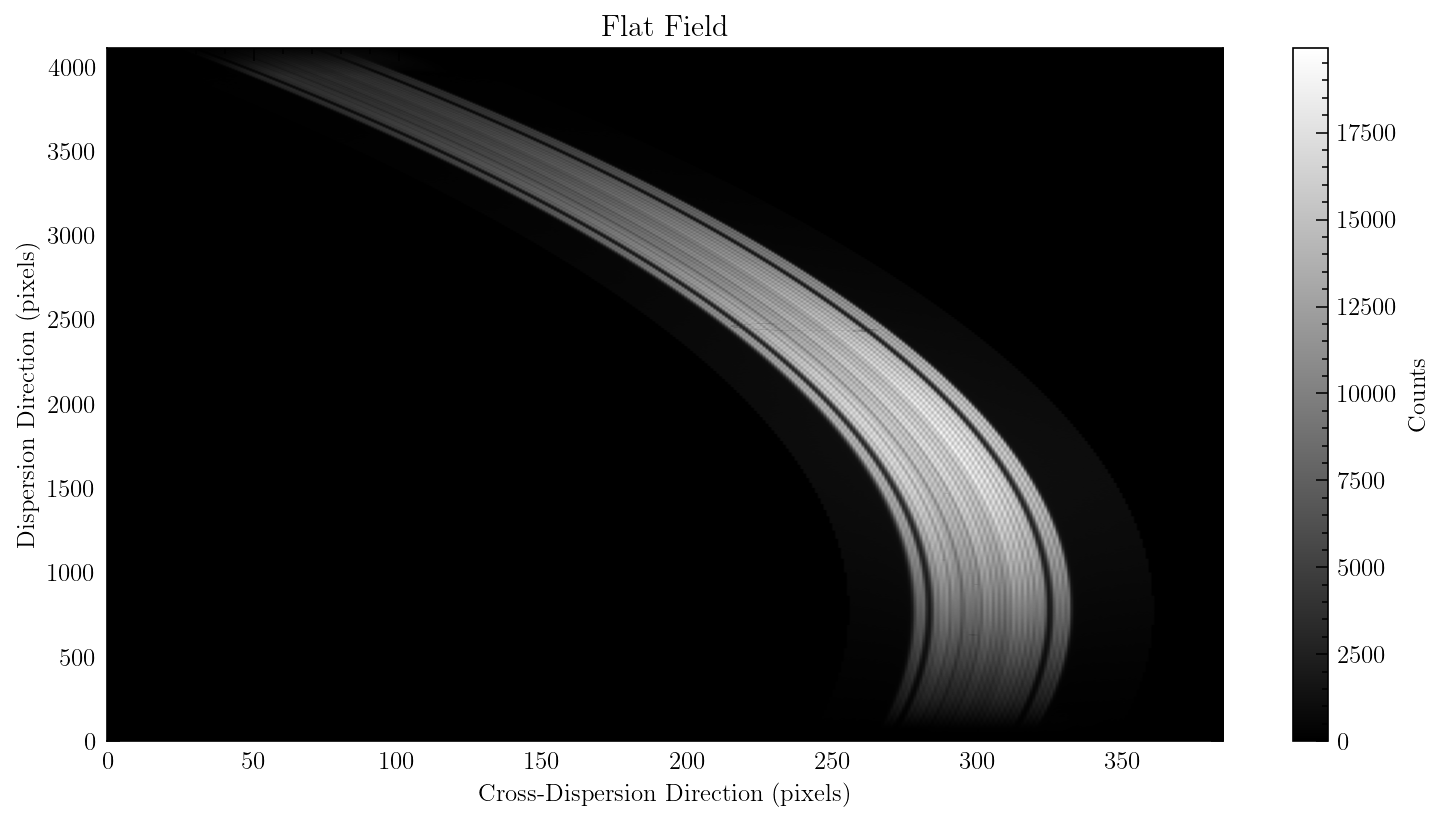

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
#Import flat field data
flat=fits.open('data/flat.fits')
flat_data=flat[0].data
#Produce a plot to double check that the tramlines are visible in the data
plt.figure(figsize=(12,6))
plt.imshow(flat_data, cmap='gray', origin='lower', aspect='auto')
plt.ylabel('Dispersion Direction (pixels)')
plt.xlabel('Cross-Dispersion Direction (pixels)')
plt.colorbar(label='Counts')
plt.title('Flat Field')
plt.show

<small> My approach to this question began by first just plotting and looking at one row of the image which, as given as a hint in the question, is the cross-dispersion profile for one of the vertical dispersion pixels. Looking at this, I could indentify the position of the dips in the profile that represented the tramlines and from there was able to develop a method to get the x-position of this tramline along each row. Thus, using a for loop that looped through all vertical dispersion pixel rows, I used np.gradients to calculate the gradient at each horizontal pixel in the row. Then, moving from the left of the profile, my code searched for the first time that the gradient dipped below a particular threshold. Through visual inspection of a few cross-dispersion profiles, I selected this threshold value to  be -5 as that was a good value which really made sure that the gradint was negative enough to be a sharp dip. Then once that first occurence of such a dip registered, this point was determined to be the x-value of the left tramline. Now, using the assumption that te distnace between the tramlines was constant, I was able to infer a likley distnace between of about 45 pixels from my sample cross-dispersion profile. Thus, I simply found the x-position of the right tramlin by adding 45 to the left-tramline x-value.  Then once I had looped through all rows in the image, I used Scipy's 1D smoothing spline tool to fit a smooth function to all of the tramline data points for the left and right tramlines respectively. I will note that I chose to fit the spline from the 100th pixel upwards as below this point was quite dark or low counts and so the tramlines were not as clear. </small>

<function matplotlib.pyplot.show(close=None, block=None)>

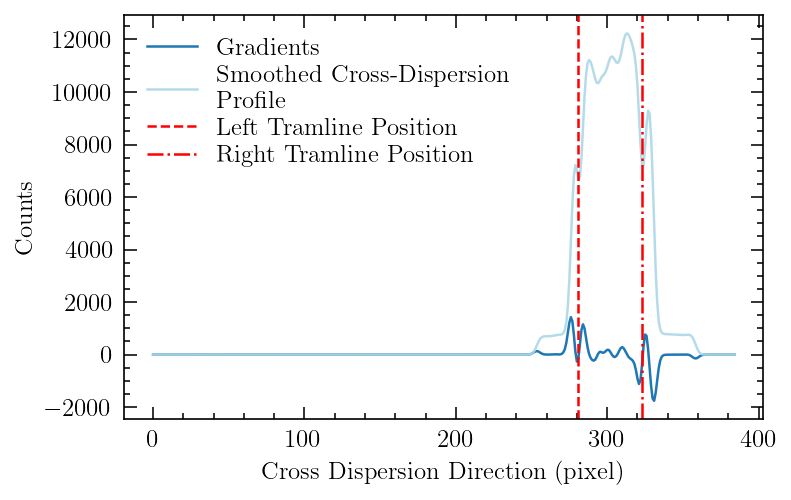

In [ ]:
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import UnivariateSpline
#First just looking at the cross-dispersion profile for one vertical dispersion pixel row
#Can determine the distance between tramlines is about 42
cross_profile=flat_data[1000,:]
#Smooth it
smoothed=gaussian_filter1d(cross_profile, sigma=2)
#Calculate the gradients along the profile
gradients=np.gradient(smoothed)
#Plot it
plt.plot(gradients, label='Gradients')
plt.plot(smoothed, color='lightblue', alpha=0.9, label='Smoothed Cross-Dispersion \n Profile')
plt.axvline(281, color='red', linestyle='--', label='Left Tramline Position')
plt.axvline(323, color='red',linestyle='-.', label='Right Tramline Position')
plt.xlabel('Cross Dispersion Direction (pixel)')
plt.ylabel('Counts')
plt.legend()
plt.show

1283113383.py: 4112 385


<function matplotlib.pyplot.show(close=None, block=None)>

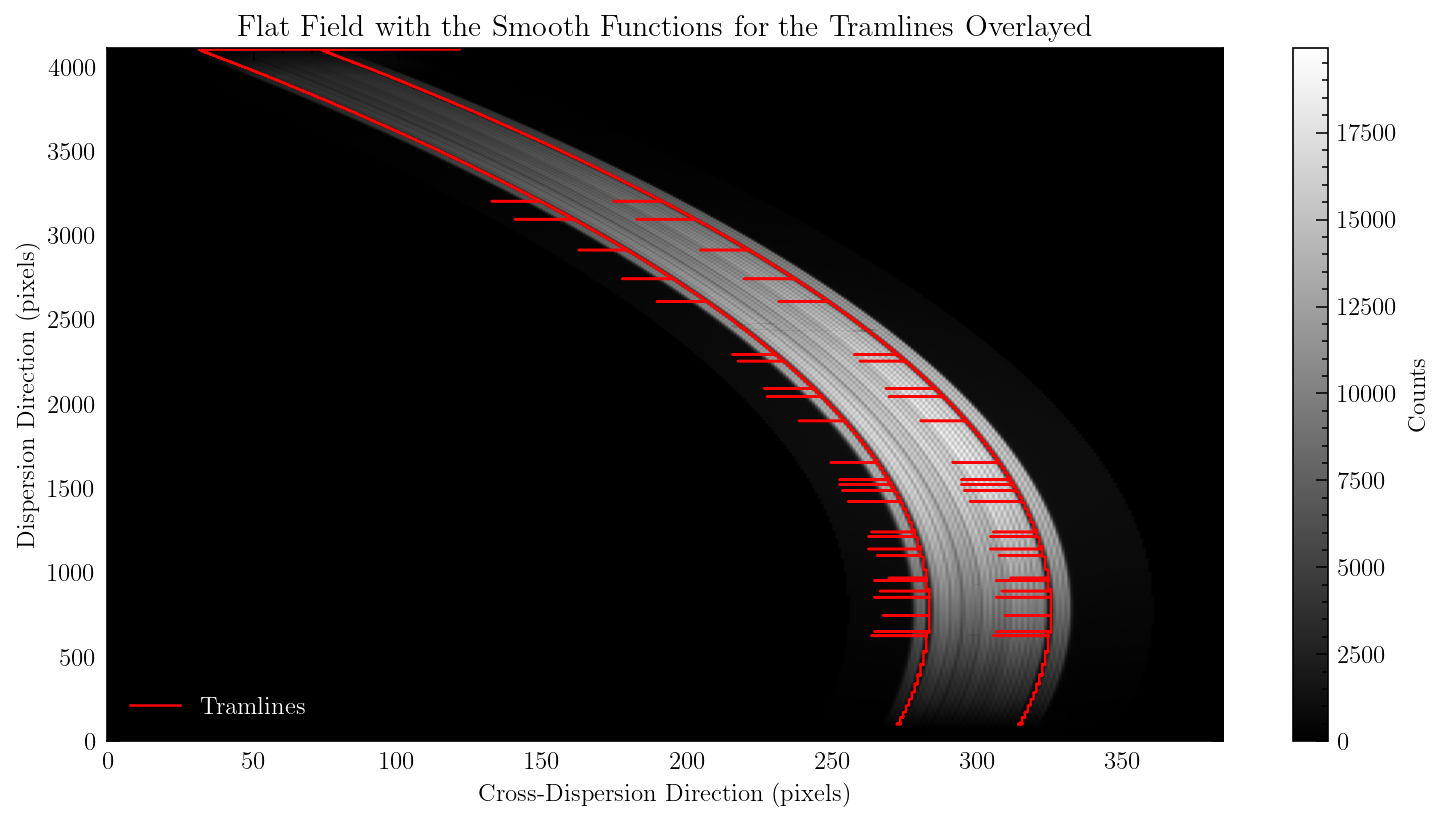

In [28]:
#Now to loop through all rows
ny, nx=np.shape(flat_data)
print(ny,nx)
#Initialise an array representing the number of disperion pixels in the y-direction
y_pix=np.arange(ny)
#Initialise arrays for the position of the left and right tram lines in terms of cross-dispersion pixel
left_tram_pos=np.zeros(ny)
right_tram_pos=np.zeros(ny)
for i in y_pix[100:]:
    cross_profile=flat_data[i,:]
    #Smooth it
    smoothed=gaussian_filter1d(cross_profile, sigma=2)
    #Calculate the gradients
    gradients=np.gradient(smoothed)
    #Define the threshold below which the gradient of the first tramline dip is expected to be
    threshold=-5
    #Find the first strong negative gradient below this
    for x in range (1, nx):
        if gradients[x]<threshold:
            #Added two here as from visual inspection of the overlaid smooth functions, it appeared it was off by this factor
            left_tram=x+2
            break
    #assuming the right tramline is about 42 pixels away from previous visual inspection
    if left_tram is None:
        right_tram=None
    else:
        right_tram=left_tram+42 
    #Adding these positions to the array
    left_tram_pos[i]=left_tram
    right_tram_pos[i]=right_tram
#Fitting a smooth function
left_smooth= UnivariateSpline(y_pix,left_tram_pos, s=5)
right_smooth= UnivariateSpline(y_pix,right_tram_pos, s=5)
#Plotting it with the tramlines overlayed
plt.figure(figsize=(12,6))
plt.imshow(flat_data, cmap='gray', origin='lower', aspect='auto')
plt.plot(left_smooth(y_pix[100:]), y_pix[100:], 'r-', label='Tramlines')
plt.plot(right_smooth(y_pix[100:]), y_pix[100:], 'r-')
plt.colorbar(label='Counts')
plt.title('Flat Field with the Smooth Functions for the Tramlines Overlayed')
plt.ylabel('Dispersion Direction (pixels)')
plt.xlabel('Cross-Dispersion Direction (pixels)')
leg = plt.legend(loc='lower left')
for text in leg.get_texts():
    text.set_color("white")
plt.show
